# Aria Gen 2, stereo depth

Working out depth from the two forward facing CV cameras, `slam-front-left` and
`slam-front-right`. Depth is what turns a mask in a flat image into a position
in the room, so nothing downstream works without it.

Kept separate from the object detection notebook on purpose, since that one
loads YOLO and SAM and takes minutes to run through.

In [1]:
from pathlib import Path

# Where does everything live ? Everything sits inside the repository now, so the
# notebooks are in <repo>/notebooks and every data folder is a sibling of that one. We
# work the repository out from the notebook's own location, which means you can rename
# the repository or move it somewhere else entirely and not a single path below breaks.
NOTEBOOKS = Path.cwd()
REPO      = NOTEBOOKS.parent

# Running this from somewhere other than the notebooks folder ? Then uncomment the line
# below, point it at the repository and everything underneath it keeps working.
# REPO = Path("/Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics")

# The heavy folders live inside the repository, which means git would cheerfully try to
# take all 2.8 GB of them if we let it. Every one of them is named in .gitignore
# instead, so they sit right here beside the code while never reaching GitHub. One
# warning follows from that. Never run git clean -x in here, because that is the command
# which deletes ignored files and the recordings cannot be made a second time.
RECORDINGS = REPO / "recordings"   # the vrs files, far too big for git
MODELS     = REPO / "models"       # yolo and sam weights, downloadable again
CACHE      = REPO / "cache"        # exported frames, the mp4, cached centroids
OUTPUTS    = REPO / "outputs"      # the deliverables, and these do go in git

# Anything we write into should exist before we try to write into it.
OUTPUTS.mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)

print("repo:      ", REPO)
print("recordings:", RECORDINGS)
print("models:    ", MODELS)
print("cache:     ", CACHE)
print("outputs:   ", OUTPUTS)

# A wrong working directory would quietly send every write below into some other folder,
# and we would only find out much later when a file turns up missing. So we stop here
# instead of guessing.
assert RECORDINGS.is_dir(), f"no recordings folder at {RECORDINGS}, set REPO by hand above"
assert MODELS.is_dir(),     f"no models folder at {MODELS}, set REPO by hand above"

repo:       /Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics
recordings: /Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics/recordings
models:     /Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics/models
cache:      /Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics/cache
outputs:    /Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics/outputs


In [2]:
from projectaria_tools.core import data_provider
from projectaria_tools.core.sensor_data import TimeDomain, TimeQueryOptions
import numpy as np
import matplotlib.pyplot as plt

vrs_file_path = str(RECORDINGS / "pouring_scooping_1_20260918_160639.vrs")

vrs_data_provider = data_provider.create_vrs_data_provider(vrs_file_path)

# The two forward cameras are the stereo pair. The side ones are for coverage
# rather than depth, because their fields of view barely overlap.
left_id = vrs_data_provider.get_stream_id_from_label("slam-front-left")
right_id = vrs_data_provider.get_stream_id_from_label("slam-front-right")
rgb_stream_id = vrs_data_provider.get_stream_id_from_label("camera-rgb")

# We anchor time to the RGB stream so that seconds here mean the same thing as
# seconds in the object detection notebook, where the spoon work was done.
first_ns = vrs_data_provider.get_first_time_ns(rgb_stream_id, TimeDomain.DEVICE_TIME)

print("left :", left_id)
print("right:", right_id)
print("rgb  :", rgb_stream_id)

left : 1201-1
right: 1201-2
rgb  : 214-1


[ProgressLogger][INFO]: 2026-09-25 01:56:23: Opening /Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics/recordings/pouring_scooping_1_20260918_160639.vrs...
[TelemetryLogger][INFO]: RecordFileReader::doOpenFile, diskfile: success, 969970952
[VRSIndexRecord][WARNING]: 12 record(s) not sorted properly. Sorting index.
[MultiRecordFileReader][DEBUG]: Opened file '/Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics/recordings/pouring_scooping_1_20260918_160639.vrs' and assigned to reader #0
[VrsDataProvider][INFO]: streamId 211-1/camera-et-left activated
[VrsDataProvider][INFO]: streamId 211-2/camera-et-right activated
[VrsDataProvider][INFO]: streamId 214-1/camera-rgb activated
[VrsDataProvider][INFO]: streamId 231-1/mic activated
[VrsDataProvider][INFO]: streamId 246-1/temperature activated
[VrsDataProvider][INFO]: streamId 247-1/baro0 activated
[VrsDataProvider][INFO]: streamId 248-1/ppg activated


left shape (512, 512), right shape (512, 512)
capture time difference: 0.002 ms


m[TelemetryLogger][INFO]: make_xprs_decoder, video/512x512/pixel=grey8/codec=H.265: H.265/SW/hevc, gray8
[XPRS][INFO]: Using VideoToolbox HW acceleration
[XPRS][INFO]: Fallback to software decoding, likely due to unsupported color format
[XprsDecoder][INFO]: Using H.265 SW decoder named 'hevc' (xprs::gray8 -> vrs::grey8)
[TelemetryLogger][INFO]: make_xprs_decoder, video/512x512/pixel=grey8/codec=H.265: H.265/SW/hevc, gray8


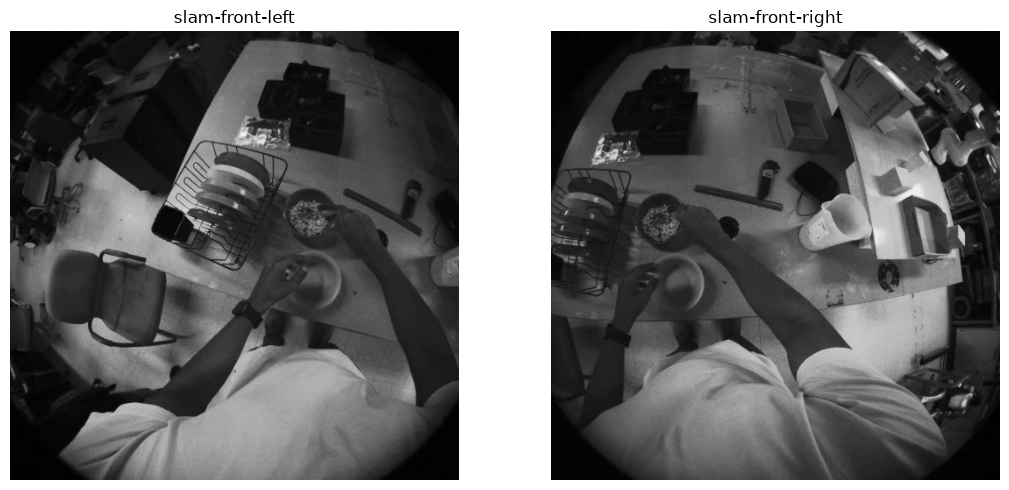

In [3]:
# We use the same frame we had a clean spoon mask on, so the depth result can be
# checked against something we already trust rather than a random moment.
t_ns = first_ns + int(32.5 * 1e9)

left_data, left_rec = vrs_data_provider.get_image_data_by_time_ns(
    left_id, t_ns, TimeDomain.DEVICE_TIME, TimeQueryOptions.CLOSEST)
right_data, right_rec = vrs_data_provider.get_image_data_by_time_ns(
    right_id, t_ns, TimeDomain.DEVICE_TIME, TimeQueryOptions.CLOSEST)

left_img = left_data.to_numpy_array()
right_img = right_data.to_numpy_array()

# Stereo depth assumes both images were taken at the same instant. They are two
# separate cameras with their own clocks, so we check rather than assume. A few
# milliseconds of skew would put moving objects in the wrong place.
skew_ms = abs(left_rec.capture_timestamp_ns - right_rec.capture_timestamp_ns) / 1e6
print(f"left shape {left_img.shape}, right shape {right_img.shape}")
print(f"capture time difference: {skew_ms:.3f} ms")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(left_img, cmap="gray")
axes[0].set_title("slam-front-left")
axes[0].axis("off")
axes[1].imshow(right_img, cmap="gray")
axes[1].set_title("slam-front-right")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [4]:
device_calib = vrs_data_provider.get_device_calibration()

left_calib = device_calib.get_camera_calib("slam-front-left")
right_calib = device_calib.get_camera_calib("slam-front-right")

# Printing what the calibration object can actually do before we call anything.
# Method names move between SDK versions, so if a call below raises we can read
# the right name straight off this line rather than guessing again.
print("available:", [m for m in dir(left_calib) if not m.startswith("_")])
print()

# The baseline is the distance between the two lenses. Depth comes out as focal
# length times baseline divided by disparity, so without this number we cannot
# convert a pixel shift into metres at all.
T_left = left_calib.get_transform_device_camera()
T_right = right_calib.get_transform_device_camera()

print("left model:", left_calib.get_model_name())
print("left focal:", left_calib.get_focal_lengths())
print("left principal point:", left_calib.get_principal_point())
print()
print("left translation in device frame: ", T_left.translation())
print("right translation in device frame:", T_right.translation())

available: ['get_focal_lengths', 'get_image_size', 'get_label', 'get_max_solid_angle', 'get_model_name', 'get_principal_point', 'get_projection_params', 'get_readout_time_sec', 'get_serial_number', 'get_time_offset_sec_device_camera', 'get_transform_device_camera', 'get_valid_radius', 'is_visible', 'model_name', 'num_parameters', 'project', 'project_no_checks', 'projection_params', 'rescale', 'unproject', 'unproject_no_checks']

left model: CameraModelType.FISHEYE624
left focal: [246.70328572 246.70328572]
left principal point: [252.94881703 255.93648182]

left translation in device frame:  [[ 3.46944695e-18  2.16840434e-19 -8.67361738e-19]]
right translation in device frame: [[ 0.13329496  0.01954659 -0.04569071]]


In [5]:
from projectaria_tools.core import calibration

# The translation prints as a 1x3 array rather than a flat triple, which is why
# the VIO tutorial indexed it with [0]. We flatten it so the arithmetic below
# reads normally.
t_left = np.asarray(T_left.translation()).reshape(-1)
t_right = np.asarray(T_right.translation()).reshape(-1)

baseline_vec = t_right - t_left
baseline = np.linalg.norm(baseline_vec)
focal = left_calib.get_focal_lengths()[0]

print(f"baseline vector: {baseline_vec}")
print(f"baseline length: {baseline * 100:.2f} cm")
print()

# A rectified pair would have the whole baseline on one axis. Ours does not, so
# how far off are we ? The two smaller components tell us how much warping the
# rectification has to do.
print(f"off axis offsets: y = {baseline_vec[1]*100:.2f} cm, z = {baseline_vec[2]*100:.2f} cm")
print()

# Before building anything, is this pair even capable of useful depth at the
# range we care about ? Disparity is focal times baseline over distance, so we
# can answer that with arithmetic rather than with a model.
print("distance   disparity   error per 1 px of disparity")
for z in [0.3, 0.5, 1.0, 2.0, 5.0]:
    disparity = focal * baseline / z
    # Differentiating the depth formula gives the sensitivity, which is what
    # actually decides whether the result is worth anything at that range.
    error = z * z / (focal * baseline)
    print(f"{z:>5.1f} m   {disparity:>7.1f} px   {error*1000:>8.1f} mm")
print()

# Rectification is the piece we have not built. Does projectaria_tools already
# provide it or do we assemble it ourselves from the undistortion helpers ?
print("calibration module:")
print([n for n in dir(calibration) if not n.startswith("_")])

baseline vector: [ 0.13329496  0.01954659 -0.04569071]
baseline length: 14.23 cm

off axis offsets: y = 1.95 cm, z = -4.57 cm

distance   disparity   error per 1 px of disparity
  0.3 m     117.0 px        2.6 mm
  0.5 m      70.2 px        7.1 mm
  1.0 m      35.1 px       28.5 mm
  2.0 m      17.5 px      114.0 mm
  5.0 m       7.0 px      712.3 mm

calibration module:
['ARIA_ET_CALIBRATION', 'ARIA_MIC_CALIBRATION', 'BAROMETER_CALIBRATION', 'BarometerCalibration', 'CALIBRATED_ALL', 'CAMERA_CALIBRATION', 'CameraCalibration', 'CameraModelType', 'CameraProjection', 'CpfType', 'DeviceCadExtrinsics', 'DeviceCalibration', 'DeviceVersion', 'FISHEYE62', 'FISHEYE624', 'GYRO_ONLINE_BIAS', 'Gen1', 'Gen2', 'IMU_CALIBRATION', 'ImuCalibration', 'KANNALA_BRANDT_K3', 'LINEAR', 'LinearRectificationModel3d', 'MAGNETOMETER_CALIBRATION', 'MICROPHONE_CALIBRATION', 'MagnetometerCalibration', 'MicrophoneCalibration', 'NEURAL_BAND_BATCH_CALIBRATION', 'NOT_VALID', 'NeuralBandBatchCalibration', 'NeuralBandEmg

In [6]:
# These are C++ bindings rather than Python functions, so inspect cannot read
# them. Pybind11 writes the signature into the docstring instead, so that is
# where we look.
print(calibration.distort_by_calibration_and_apply_rotation.__doc__)
print()
print("-" * 70)
print()
print(calibration.get_linear_camera_calibration.__doc__)
print()
print("-" * 70)
print()
print(calibration.distort_by_calibration.__doc__)

distort_by_calibration_and_apply_rotation(*args, **kwargs)
Overloaded function.

1. distort_by_calibration_and_apply_rotation(arraySrc: typing.Annotated[numpy.typing.ArrayLike, numpy.uint8], dstCalib: _core_pybinds.calibration.CameraCalibration, srcCalib: _core_pybinds.calibration.CameraCalibration, so3_srcCalib_dstCalib: SO3, method: _core_pybinds.image.InterpolationMethod = <InterpolationMethod.BILINEAR: 1>) -> numpy.typing.NDArray[numpy.float32] | numpy.typing.NDArray[numpy.uint8] | numpy.typing.NDArray[numpy.uint16] | numpy.typing.NDArray[numpy.uint64] | numpy.typing.NDArray[Eigen::half]

Distorts an input image to swap its underlying image distortion model, while applying a rotation to the camera ray. This can be used for stereo rectification.

2. distort_by_calibration_and_apply_rotation(arraySrc: typing.Annotated[numpy.typing.ArrayLike, numpy.float32], dstCalib: _core_pybinds.calibration.CameraCalibration, srcCalib: _core_pybinds.calibration.CameraCalibration, so3_srcCalib_dstCa

In [7]:
# The positions told us the cameras sit apart. The rotations tell us whether
# they also point in different directions, which they almost certainly do since
# the frame is curved. This is the part rectification has to undo.
print("SE3 methods:", [m for m in dir(T_left) if not m.startswith("_")])
print()

R_left = np.asarray(T_left.rotation().to_matrix())
R_right = np.asarray(T_right.rotation().to_matrix())

# The relative rotation from the left camera to the right one. If the cameras
# were parallel this would be the identity, so how far it strays from that is
# how much work the rectification has to do.
R_rel = R_left.T @ R_right

print("relative rotation, left to right:")
print(R_rel)

# A rotation matrix is hard to read, so we also express it as an angle. How far
# apart are the two optical axes in plain degrees ?
angle_rad = np.arccos(np.clip((np.trace(R_rel) - 1) / 2, -1.0, 1.0))
print(f"\nangle between the two cameras: {np.degrees(angle_rad):.2f} degrees")

SE3 methods: ['exp', 'from_matrix', 'from_matrix3x4', 'from_quat_and_translation', 'inverse', 'log', 'rot_x', 'rot_y', 'rot_z', 'rotation', 'to_matrix', 'to_matrix3x4', 'to_quat_and_translation', 'translation']

relative rotation, left to right:
[[ 0.76548162 -0.25435932  0.59104926]
 [ 0.25361437  0.96346007  0.08616526]
 [-0.5913693   0.08394067  0.80202015]]

angle between the two cameras: 40.05 degrees


In [8]:
# Everything here is in the left camera frame, which is convenient because the
# left camera is also the device origin.
t_left_v = np.asarray(T_left.translation()).reshape(-1)
t_right_v = np.asarray(T_right.translation()).reshape(-1)

# The right camera expressed in left camera coordinates.
R_LR = R_left.T @ R_right
t_LR = R_left.T @ (t_right_v - t_left_v)

# A rectified pair has three properties. Both cameras share one orientation,
# their x axis runs along the baseline and their image rows therefore line up.
# So we build that frame directly from the baseline.
new_x = t_LR / np.linalg.norm(t_LR)

# The new y axis has to be perpendicular to the baseline. We get it by crossing
# the baseline with the left camera's optical axis, which keeps the rectified
# view pointing roughly where the left camera was already looking.
optical_axis = np.array([0.0, 0.0, 1.0])
new_y = np.cross(optical_axis, new_x)
new_y = new_y / np.linalg.norm(new_y)

# And the third axis follows from the other two, so the frame stays right handed.
new_z = np.cross(new_x, new_y)

# Rows are the new basis vectors written in the old frame, which makes this the
# rotation that takes left camera coordinates into rectified coordinates.
R_rect_left = np.vstack([new_x, new_y, new_z])

# The right camera reaches the same rectified frame by going through the left
# one first, since R_LR already expresses right camera rays in left coordinates.
R_rect_right = R_rect_left @ R_LR

# Three checks before we trust any of this. Are the frames actually orthonormal ?
# And does the baseline really land on the x axis once rectified ?
print("left rect orthonormal error :", np.abs(R_rect_left @ R_rect_left.T - np.eye(3)).max())
print("right rect orthonormal error:", np.abs(R_rect_right @ R_rect_right.T - np.eye(3)).max())
print("determinants:", np.linalg.det(R_rect_left), np.linalg.det(R_rect_right))
print()

# The baseline in the rectified frame should be purely along x. If the y and z
# components are not essentially zero then the rows will not line up and every
# disparity we measure afterwards is meaningless.
baseline_rect = R_rect_left @ t_LR
print("baseline in rectified frame:", baseline_rect)
print(f"off axis residual: {np.abs(baseline_rect[1:]).max():.2e} m")
print()

# The warp function wants the rotation the other way round, from the rectified
# frame back into each original camera, so we transpose both.
so3_left = R_rect_left.T
so3_right = R_rect_right.T
print("rotations ready, so3_left and so3_right")

left rect orthonormal error : 2.220446049250313e-16
right rect orthonormal error: 5.925164872633282e-17
determinants: 1.0 0.9999999999999999

baseline in rectified frame: [1.42257709e-01 3.46944695e-18 6.93889390e-18]
off axis residual: 6.94e-18 m

rotations ready, so3_left and so3_right


SO3 methods: ['exp', 'from_matrix', 'from_quat', 'inverse', 'log', 'to_matrix', 'to_quat']

rectified camera: 512x512, focal 246.7, field of view 92.1 degrees

rectified shapes: (512, 512) (512, 512)


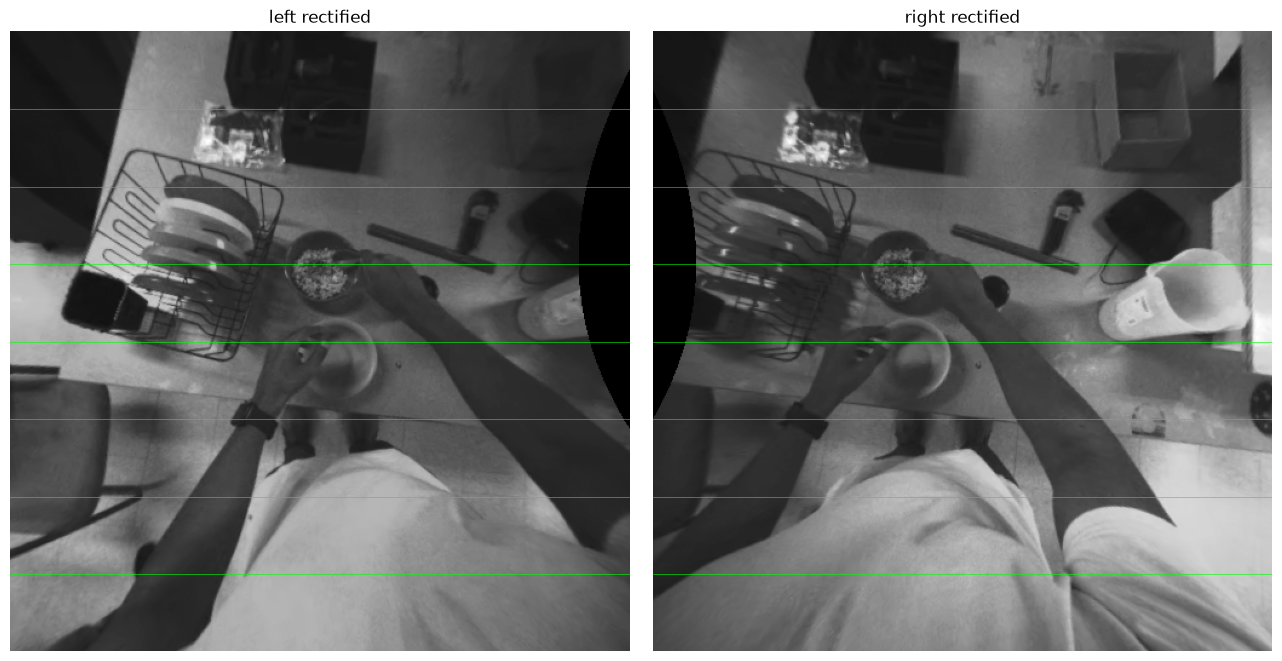

In [9]:
from projectaria_tools.core.sophus import SO3

# The warp function wants an SO3 rather than a plain array. Construction methods
# also vary between versions. Printing first means a failure below is
# diagnosable from the same output.
print("SO3 methods:", [m for m in dir(SO3) if not m.startswith("_")])
print()

# The rectified pair is a virtual camera we invent, so we choose its intrinsics.
# Starting at the source camera's own focal and size keeps the comparison
# honest. If the overlap turns out too small we widen by lowering RECT_FOCAL
# and raising RECT_SIZE, which trades resolution for field of view.
RECT_FOCAL = float(left_calib.get_focal_lengths()[0])
RECT_SIZE = 512

rect_calib = calibration.get_linear_camera_calibration(
    RECT_SIZE, RECT_SIZE, RECT_FOCAL, "rectified")

fov_deg = 2 * np.degrees(np.arctan(RECT_SIZE / 2 / RECT_FOCAL))
print(f"rectified camera: {RECT_SIZE}x{RECT_SIZE}, focal {RECT_FOCAL:.1f}, "
      f"field of view {fov_deg:.1f} degrees")
print()

# Both images get warped into that same virtual geometry, each with its own
# rotation. The function walks destination pixels and asks where each came
# from, which is why it wants the rotation from rectified back to camera.
left_rect = calibration.distort_by_calibration_and_apply_rotation(
    left_img, rect_calib, left_calib, SO3.from_matrix(so3_left))
right_rect = calibration.distort_by_calibration_and_apply_rotation(
    right_img, rect_calib, right_calib, SO3.from_matrix(so3_right))

print("rectified shapes:", left_rect.shape, right_rect.shape)

# This is the test that matters. In a correctly rectified pair a point in the
# world lands on the same row in both images, so a horizontal line drawn across
# both should touch the same features. Does it ? If the lines cut through a
# bowl at different heights then something is still wrong and no disparity we
# measure afterwards would mean anything.
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, img, title in ((axes[0], left_rect, "left rectified"),
                       (axes[1], right_rect, "right rectified")):
    ax.imshow(img, cmap="gray")
    for y in range(64, RECT_SIZE, 64):
        ax.axhline(y, color="lime", linewidth=0.6, alpha=0.7)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

pixels with a disparity: 37.2%
disparity range: 0.6 to 127.0 px

  5th percentile depth: 0.28 m
 25th percentile depth: 0.51 m
 50th percentile depth: 0.69 m
 75th percentile depth: 0.74 m
 95th percentile depth: 17.55 m


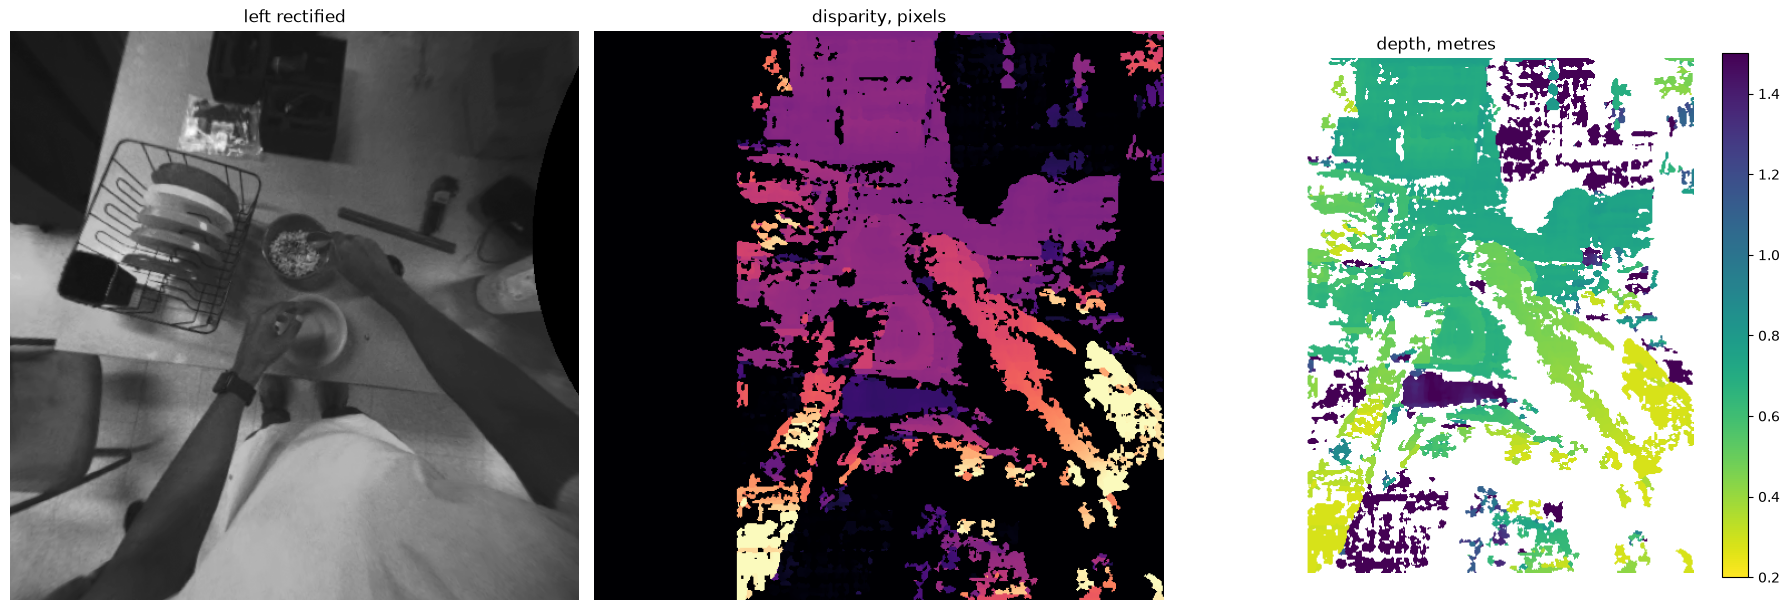

In [10]:
import cv2

# Our own arithmetic said a spoon at half a metre sits around 70 pixels of
# disparity and a hand at 30 cm around 117, so the search has to cover at least
# that. The value has to be a multiple of sixteen.
NUM_DISP = 128
BLOCK = 5

stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=NUM_DISP,
    blockSize=BLOCK,
    # These two penalise disparity changing between neighbouring pixels, gently
    # for small steps and hard for large ones, which keeps surfaces smooth
    # without flattening real depth edges. The multipliers are the standard
    # recipe for a single channel image.
    P1=8 * 1 * BLOCK ** 2,
    P2=32 * 1 * BLOCK ** 2,
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32,
    mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY,
)

# SGBM hands back fixed point with four fractional bits, so we scale to get
# real pixels of disparity.
disparity = stereo.compute(left_rect, right_rect).astype(np.float32) / 16.0

# Anything at or below zero never found a match, usually the black wedges or
# the blank tabletop where there is no texture to match on.
valid = disparity > 0
print(f"pixels with a disparity: {valid.mean() * 100:.1f}%")
print(f"disparity range: {disparity[valid].min():.1f} to {disparity[valid].max():.1f} px")
print()

# And the conversion we have been building towards all along. Focal times
# baseline over disparity gives metres.
depth = np.full_like(disparity, np.nan)
depth[valid] = RECT_FOCAL * baseline / disparity[valid]

# Does the result sit where a table and a pair of hands should be ? Percentiles
# are more honest than a min and max, which any single bad pixel can dominate.
d = depth[valid]
for p in [5, 25, 50, 75, 95]:
    print(f"{p:>3}th percentile depth: {np.percentile(d, p):.2f} m")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(left_rect, cmap="gray")
axes[0].set_title("left rectified")
axes[0].axis("off")

axes[1].imshow(disparity, cmap="magma", vmin=0, vmax=NUM_DISP)
axes[1].set_title("disparity, pixels")
axes[1].axis("off")

# We clip the depth display to arm's reach, because that is the range this
# camera pair is actually good at and a few far away pixels would otherwise
# wash out all the contrast in the part we care about.
im = axes[2].imshow(depth, cmap="viridis_r", vmin=0.2, vmax=1.5)
axes[2].set_title("depth, metres")
axes[2].axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

In [11]:
# A depth map that looks sensible can still be wrong by a scale factor or an
# offset. The hand tracking gives us ground truth we already trust, so we check
# the stereo answer against it rather than against our own intuition.
hand_sid = vrs_data_provider.get_stream_id_from_label("handtracking")
hand = vrs_data_provider.get_interpolated_hand_pose_data(
    hand_sid, t_ns, TimeDomain.DEVICE_TIME)

# Depth beyond two metres is not worth keeping from this pair, since our own
# error table said a single pixel costs us eleven centimetres out there.
MAX_DEPTH = 2.0
clean = valid & (depth < MAX_DEPTH)
print(f"pixels within {MAX_DEPTH} m: {clean.mean() * 100:.1f}%")
print()

def check_point(name, p_device):
    """Project a known 3D point into the rectified image and compare depths."""
    p = np.asarray(p_device).reshape(-1)[:3]

    # Into left camera coordinates, then into the rectified frame, using the
    # same rotations the images were warped with.
    p_leftcam = R_left.T @ (p - t_left_v)
    p_rect = R_rect_left @ p_leftcam

    # A point behind the camera cannot be projected, so we say so rather than
    # letting project() fail in a confusing way.
    if p_rect[2] <= 0:
        print(f"{name}: behind the rectified camera, skipping")
        return

    px = rect_calib.project(p_rect)
    if px is None:
        print(f"{name}: falls outside the rectified image")
        return

    u, v = int(round(float(px[0]))), int(round(float(px[1])))
    if not (0 <= u < RECT_SIZE and 0 <= v < RECT_SIZE):
        print(f"{name}: projects to ({u}, {v}), off the image")
        return

    # We sample a small window rather than one pixel, because a single pixel may
    # be one of the 63% with no match at all.
    half = 5
    win = depth[max(0, v-half):v+half+1, max(0, u-half):u+half+1]
    win = win[np.isfinite(win) & (win < MAX_DEPTH)]

    truth = p_rect[2]
    if win.size == 0:
        print(f"{name}: at ({u}, {v}), truth {truth:.3f} m, no stereo depth nearby")
        return

    measured = np.median(win)
    print(f"{name}: at ({u}, {v})  truth {truth:.3f} m  "
          f"stereo {measured:.3f} m  error {measured - truth:+.3f} m")

if hand is not None:
    for side, label in ((hand.left_hand, "left"), (hand.right_hand, "right")):
        if side is None:
            print(f"{label} hand: not tracked at this moment")
            continue
        check_point(f"{label} wrist", side.get_wrist_position_device())
        check_point(f"{label} palm ", side.get_palm_position_device())
else:
    print("no hand pose at this timestamp")

pixels within 2.0 m: 32.7%

left wrist: at (217, 300)  truth 0.458 m  stereo 1.165 m  error +0.707 m
left palm : at (232, 264), truth 0.480 m, no stereo depth nearby
right wrist: at (334, 225)  truth 0.461 m  stereo 0.481 m  error +0.020 m
right palm : at (311, 198)  truth 0.491 m  stereo 0.489 m  error -0.002 m


points from this frame: 85,830
x range: -0.34 to 2.32 m
y range: -1.78 to 2.05 m
z range: 0.17 to 2.13 m

nearest cloud point to the right wrist: 15.6 mm


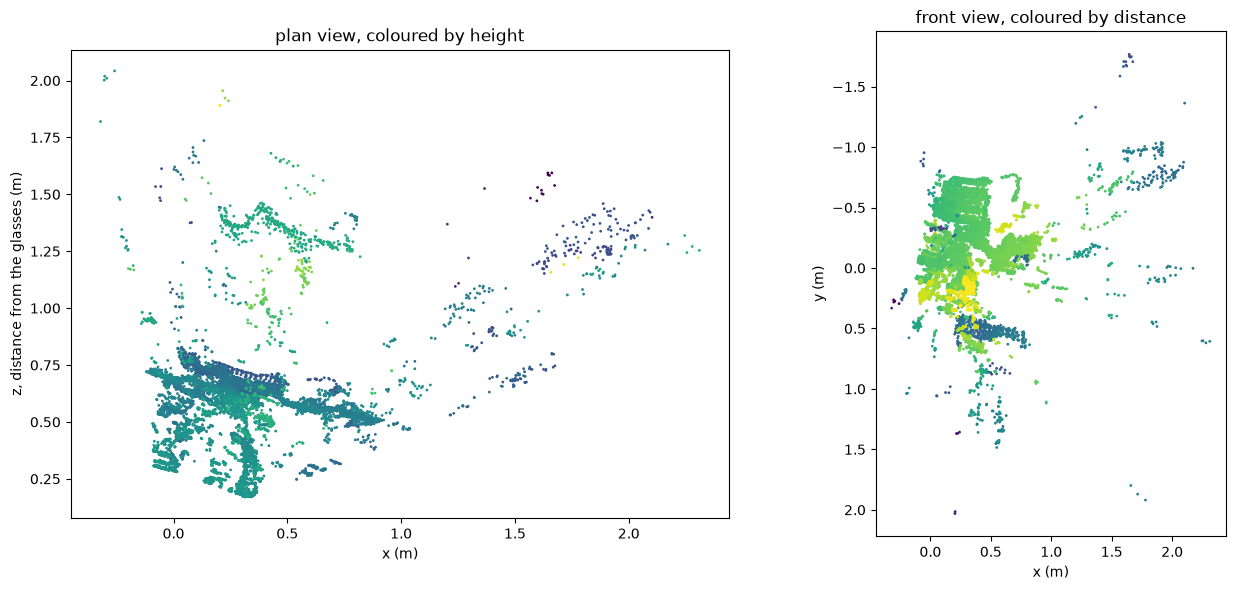

In [12]:
# The rectified camera is linear, so unprojection is a formula rather than a
# function call. Doing it with numpy means one pass over the array instead of a
# quarter of a million calls into C++.
cx, cy = [float(v) for v in rect_calib.get_principal_point()]
f = RECT_FOCAL

vs, us = np.nonzero(clean)
zs = depth[vs, us]

# The standard pinhole relation, run backwards. A pixel plus a distance is
# enough to place a point in space once we know where the optical centre sits.
xs = (us - cx) * zs / f
ys = (vs - cy) * zs / f

pts_rect = np.stack([xs, ys, zs], axis=1)
print(f"points from this frame: {len(pts_rect):,}")

# Those points live in the rectified frame, which is a virtual camera we made
# up. Everything else in this project, the hands and the device pose, is in the
# device frame, so we move the cloud there.
pts_leftcam = pts_rect @ R_rect_left          # transpose of the inverse
pts_device = pts_leftcam @ R_left.T + t_left_v

print(f"x range: {pts_device[:, 0].min():.2f} to {pts_device[:, 0].max():.2f} m")
print(f"y range: {pts_device[:, 1].min():.2f} to {pts_device[:, 1].max():.2f} m")
print(f"z range: {pts_device[:, 2].min():.2f} to {pts_device[:, 2].max():.2f} m")
print()

# The check that costs nothing. If the wrist we validated a moment ago does not
# land inside this cloud then the frame conversion above is wrong, however
# healthy the depth map itself was.
if hand is not None and hand.right_hand is not None:
    w = np.asarray(hand.right_hand.get_wrist_position_device()).reshape(-1)[:3]
    d_to_cloud = np.linalg.norm(pts_device - w, axis=1).min()
    print(f"nearest cloud point to the right wrist: {d_to_cloud * 1000:.1f} mm")

# Looking down the device's z axis gives a plan view, which is the easiest way
# to see whether the geometry is a room or a mess.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sub = pts_device[::7]   # thinning purely so the scatter stays readable

axes[0].scatter(sub[:, 0], sub[:, 2], c=sub[:, 1], cmap="viridis", s=1)
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("z, distance from the glasses (m)")
axes[0].set_title("plan view, coloured by height")
axes[0].set_aspect("equal")

axes[1].scatter(sub[:, 0], sub[:, 1], c=sub[:, 2], cmap="viridis_r", s=1)
axes[1].invert_yaxis()
axes[1].set_xlabel("x (m)")
axes[1].set_ylabel("y (m)")
axes[1].set_title("front view, coloured by distance")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

rgb frame (1512, 2016, 3), mask (1512, 2016), 3,356 pixels in the mask

points in front of the rgb camera: 85,830 of 85,830
points landing inside the mask: 244

object centre in the device frame: [0.282, -0.149, 0.608] m
distance from the glasses: 0.687 m
extent: 4.5 x 5.3 x 9.4 cm
distance from the right wrist: 25.7 cm


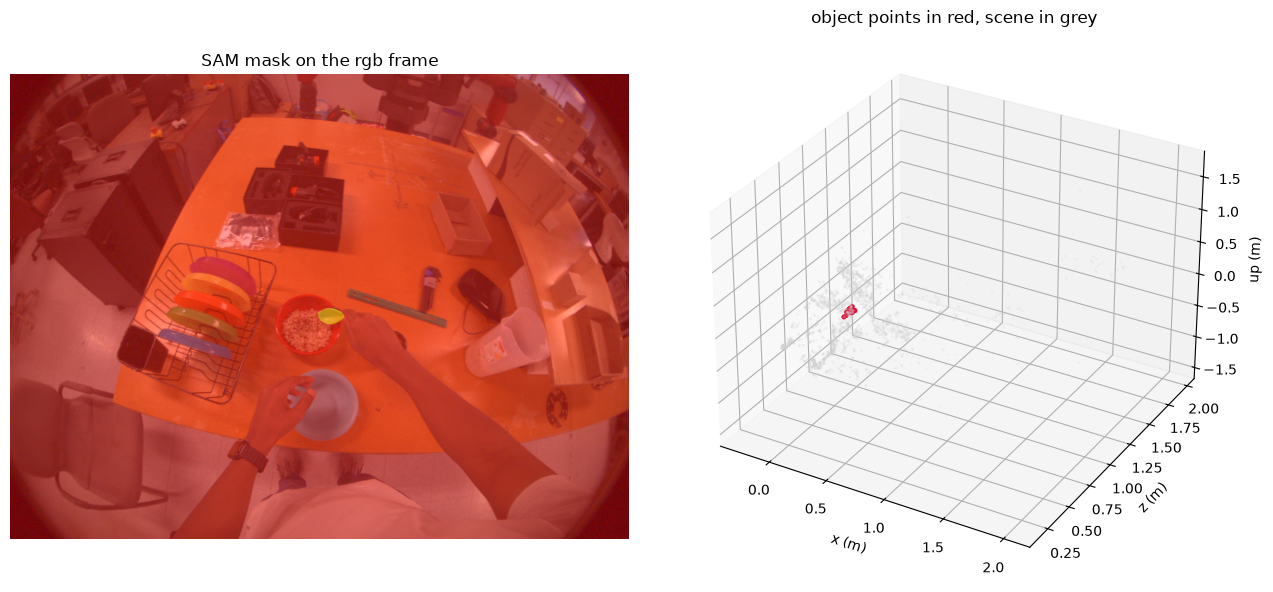

In [13]:
from ultralytics import SAM

# The mask was computed in the other notebook, so we recreate it here rather
# than carrying state between files. One frame is quick, unlike the video
# propagation.
sam = SAM(str(MODELS / "sam2_b.pt"))

rgb_data, rgb_rec = vrs_data_provider.get_image_data_by_time_ns(
    rgb_stream_id, t_ns, TimeDomain.DEVICE_TIME, TimeQueryOptions.CLOSEST)
rgb_img = rgb_data.to_numpy_array()

# The prompt point that worked in the object detection notebook, in full frame coordinates.
sam_res = sam(rgb_img, points=[[1052, 780]], labels=[1], verbose=False)[0]
mask = sam_res.masks.data[0].cpu().numpy() > 0.5

print(f"rgb frame {rgb_img.shape}, mask {mask.shape}, {mask.sum():,} pixels in the mask")
print()

# The RGB camera sits somewhere else on the frame from the CV cameras, so the
# cloud has to be moved into its coordinates before we can ask which pixel each
# point lands on.
rgb_calib = device_calib.get_camera_calib("camera-rgb")
T_rgb = rgb_calib.get_transform_device_camera()
R_rgb = np.asarray(T_rgb.rotation().to_matrix())
t_rgb = np.asarray(T_rgb.translation()).reshape(-1)

pts_rgbcam = (pts_device - t_rgb) @ R_rgb

# Points behind the RGB camera cannot project, so we drop them before spending
# any time on them.
in_front = pts_rgbcam[:, 2] > 0
print(f"points in front of the rgb camera: {in_front.sum():,} of {len(pts_rgbcam):,}")

mh, mw = mask.shape
object_idx = []

# project() is a per point call into C++, so this loop is the slow part. Is it
# worth vectorising ? Not yet, a few tens of thousands of calls take seconds.
for i in np.nonzero(in_front)[0]:
    px = rgb_calib.project(pts_rgbcam[i])
    if px is None:
        continue
    u, v = int(px[0]), int(px[1])
    if 0 <= u < mw and 0 <= v < mh and mask[v, u]:
        object_idx.append(i)

object_idx = np.array(object_idx, dtype=int)
obj_pts = pts_device[object_idx]

print(f"points landing inside the mask: {len(obj_pts):,}")
print()

if len(obj_pts) > 0:
    centre = obj_pts.mean(axis=0)
    print(f"object centre in the device frame: "
          f"[{centre[0]:.3f}, {centre[1]:.3f}, {centre[2]:.3f}] m")
    print(f"distance from the glasses: {np.linalg.norm(centre):.3f} m")
    extent = obj_pts.max(axis=0) - obj_pts.min(axis=0)
    print(f"extent: {extent[0]*100:.1f} x {extent[1]*100:.1f} x {extent[2]*100:.1f} cm")

    # Is this actually the spoon ? It should be within a few centimetres of the
    # right hand, because that is the hand holding it.
    if hand is not None and hand.right_hand is not None:
        w = np.asarray(hand.right_hand.get_wrist_position_device()).reshape(-1)[:3]
        print(f"distance from the right wrist: {np.linalg.norm(centre - w)*100:.1f} cm")

    fig = plt.figure(figsize=(13, 6))

    ax = fig.add_subplot(1, 2, 1)
    ax.imshow(rgb_img)
    ax.imshow(mask, alpha=0.4, cmap="autumn")
    ax.set_title("SAM mask on the rgb frame")
    ax.axis("off")

    ax = fig.add_subplot(1, 2, 2, projection="3d")
    bg = pts_device[::40]
    ax.scatter(bg[:, 0], bg[:, 2], -bg[:, 1], s=1, c="lightgrey", alpha=0.4)
    ax.scatter(obj_pts[:, 0], obj_pts[:, 2], -obj_pts[:, 1], s=6, c="crimson")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("z (m)")
    ax.set_zlabel("up (m)")
    ax.set_title("object points in red, scene in grey")

    plt.tight_layout()
    plt.show()
else:
    print("no points fell inside the mask, which needs explaining before going on")

candidate points: 244
  5th percentile distance: 0.674 m
 10th percentile distance: 0.676 m
 25th percentile distance: 0.681 m
 50th percentile distance: 0.687 m
 75th percentile distance: 0.694 m
 95th percentile distance: 0.705 m

kept as the visible surface: 244 of 244 points
discarded as background: 0

centre: [0.282, -0.149, 0.608] m
distance from the glasses: 0.687 m
extent: 4.5 x 5.3 x 9.4 cm
distance from the right wrist: 25.7 cm


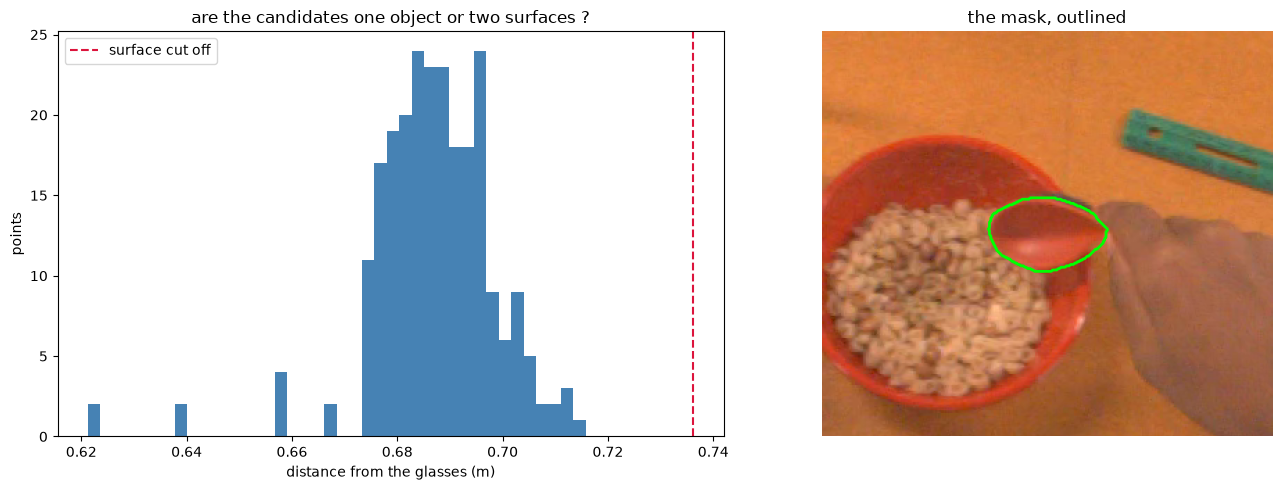

In [14]:
# Distance from the glasses for each candidate point. If the table is leaking in
# behind the spoon then this will not be one tight group, it will be two.
dists = np.linalg.norm(obj_pts, axis=1)

print(f"candidate points: {len(dists)}")
for p in [5, 10, 25, 50, 75, 95]:
    print(f"{p:>3}th percentile distance: {np.percentile(dists, p):.3f} m")
print()

# The mask describes a visible surface, so anything much further away than the
# nearest points is behind the object rather than part of it. Six centimetres is
# a little more than a spoon is deep, which gives us room without swallowing the
# tabletop.
DEPTH_WINDOW = 0.06

near = np.percentile(dists, 10)
keep = dists < near + DEPTH_WINDOW
surface_pts = obj_pts[keep]

print(f"kept as the visible surface: {keep.sum()} of {len(dists)} points")
print(f"discarded as background: {(~keep).sum()}")
print()

centre = surface_pts.mean(axis=0)
extent = surface_pts.max(axis=0) - surface_pts.min(axis=0)
print(f"centre: [{centre[0]:.3f}, {centre[1]:.3f}, {centre[2]:.3f}] m")
print(f"distance from the glasses: {np.linalg.norm(centre):.3f} m")
print(f"extent: {extent[0]*100:.1f} x {extent[1]*100:.1f} x {extent[2]*100:.1f} cm")

if hand is not None and hand.right_hand is not None:
    w = np.asarray(hand.right_hand.get_wrist_position_device()).reshape(-1)[:3]
    print(f"distance from the right wrist: {np.linalg.norm(centre - w)*100:.1f} cm")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# The histogram is the evidence. Two humps means the split above is real rather
# than something we imposed on the data.
axes[0].hist(dists, bins=40, color="steelblue")
axes[0].axvline(near + DEPTH_WINDOW, color="crimson", linestyle="--",
                label="surface cut off")
axes[0].set_xlabel("distance from the glasses (m)")
axes[0].set_ylabel("points")
axes[0].set_title("are the candidates one object or two surfaces ?")
axes[0].legend()

# And a proper look at the mask, cropped so it is actually visible rather than
# lost in two million pixels.
ys, xs = np.nonzero(mask)
pad = 120
y0, y1 = max(0, ys.min()-pad), min(mask.shape[0], ys.max()+pad)
x0, x1 = max(0, xs.min()-pad), min(mask.shape[1], xs.max()+pad)

axes[1].imshow(rgb_img[y0:y1, x0:x1])
axes[1].contour(mask[y0:y1, x0:x1], levels=[0.5], colors="lime", linewidths=2)
axes[1].set_title("the mask, outlined")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [15]:
from pathlib import Path
from ultralytics.models.sam import SAM2VideoPredictor

# The object detection notebook cached the centroids but threw the masks away. We need
# the masks themselves to pick out which 3D points belong to the object.
video_path = str(CACHE / "pour_fwd_325_37.mp4")

overrides = dict(conf=0.25, task="segment", mode="predict",
                 imgsz=1024, model=str(MODELS / "sam2_b.pt"), save=False, verbose=False)
predictor = SAM2VideoPredictor(overrides=overrides)
track = predictor(source=video_path, points=[[1052, 780]], labels=[1])

print(f"frames tracked: {len(track)}")

Ultralytics 8.4.157 🚀 Python-3.12.14 torch-2.13.0 CPU (Apple M1)
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

frames tracked: 136


In [16]:
# Frames 0 to 100 were the ones where the mask stayed on the spoon, so we use
# that range rather than the full 136 and inherit the drift.
N_FRAMES = 100
START_S = 32.5

traj = []
clouds = []

# Projecting all eighty thousand points per frame would be slow, so we only test
# points near where the object was last seen. Is that circular ? Only mildly:
# the spoon cannot teleport between frames a thirtieth of a second apart.
last_centre = centre.copy()
SEARCH_RADIUS = 0.25

for k in range(N_FRAMES):
    tk_ns = first_ns + int((START_S + k / 30.0) * 1e9)

    ld, _ = vrs_data_provider.get_image_data_by_time_ns(
        left_id, tk_ns, TimeDomain.DEVICE_TIME, TimeQueryOptions.CLOSEST)
    rd, _ = vrs_data_provider.get_image_data_by_time_ns(
        right_id, tk_ns, TimeDomain.DEVICE_TIME, TimeQueryOptions.CLOSEST)

    lr = calibration.distort_by_calibration_and_apply_rotation(
        ld.to_numpy_array(), rect_calib, left_calib, SO3.from_matrix(so3_left))
    rr = calibration.distort_by_calibration_and_apply_rotation(
        rd.to_numpy_array(), rect_calib, right_calib, SO3.from_matrix(so3_right))

    disp = stereo.compute(lr, rr).astype(np.float32) / 16.0
    ok = (disp > 0)
    dep = np.full_like(disp, np.nan)
    dep[ok] = RECT_FOCAL * baseline / disp[ok]
    ok &= (dep < MAX_DEPTH)

    v_i, u_i = np.nonzero(ok)
    z_i = dep[v_i, u_i]
    p_rect = np.stack([(u_i - cx) * z_i / f, (v_i - cy) * z_i / f, z_i], axis=1)
    p_dev = (p_rect @ R_rect_left) @ R_left.T + t_left_v

    # Narrow to the neighbourhood of the last sighting before the expensive part.
    near_idx = np.nonzero(np.linalg.norm(p_dev - last_centre, axis=1) < SEARCH_RADIUS)[0]
    if near_idx.size == 0:
        traj.append((k, np.nan, np.nan, np.nan, 0))
        continue

    m_k = track[k].masks.data[0].cpu().numpy() > 0.5
    p_rgb = (p_dev[near_idx] - t_rgb) @ R_rgb

    hits = []
    for j, p in zip(near_idx, p_rgb):
        if p[2] <= 0:
            continue
        px = rgb_calib.project(p)
        if px is None:
            continue
        u, v = int(px[0]), int(px[1])
        if 0 <= u < mw and 0 <= v < mh and m_k[v, u]:
            hits.append(j)

    if not hits:
        traj.append((k, np.nan, np.nan, np.nan, 0))
        continue

    pts_k = p_dev[np.array(hits)]
    c_k = pts_k.mean(axis=0)
    last_centre = c_k

    traj.append((k, c_k[0], c_k[1], c_k[2], len(pts_k)))
    clouds.append(pts_k)

    if k % 20 == 0:
        print(f"frame {k:>3}: {len(pts_k):>4} points, "
              f"centre [{c_k[0]:.3f}, {c_k[1]:.3f}, {c_k[2]:.3f}]")

traj = np.array(traj, dtype=float)
found = ~np.isnan(traj[:, 1])
print()
print(f"frames with a 3D position: {found.sum()} of {N_FRAMES}")
print(f"median points per frame: {np.median(traj[found, 4]):.0f}")

frame   0:  251 points, centre [0.282, -0.148, 0.607]
frame  20:  180 points, centre [0.314, -0.102, 0.610]
frame  40:  167 points, centre [0.304, -0.111, 0.559]
frame  60:  213 points, centre [0.337, -0.086, 0.480]
frame  80:  126 points, centre [0.314, -0.106, 0.522]

frames with a 3D position: 100 of 100
median points per frame: 187


usable vio poses: 660 of 670
frames placed in the room: 100

device frame span: x 0.060 m, y 0.084 m, z 0.165 m
room frame span  : x 0.188 m, y 0.182 m, z 0.188 m


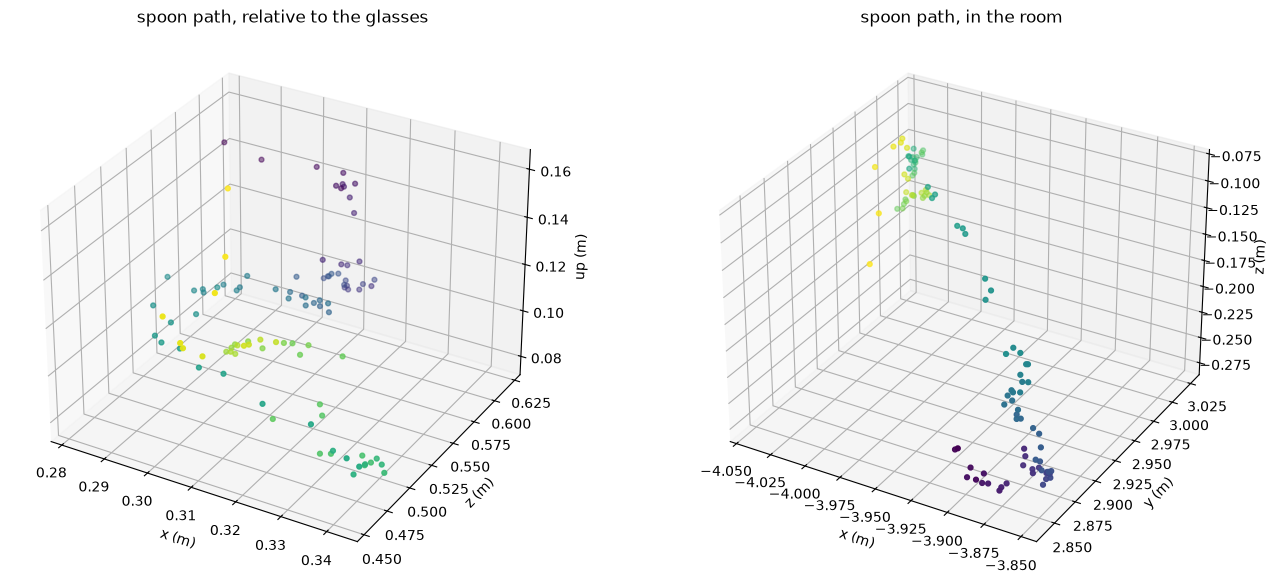

In [17]:
from projectaria_tools.core.sensor_data import VioStatus, TrackingQuality

vio_id = vrs_data_provider.get_stream_id_from_label("vio")

# VIO runs at ten a second while our frames are at thirty, so rather than
# querying per frame we read every sample once and match by time afterwards.
vio_t, vio_M = [], []
for i in range(vrs_data_provider.get_num_data(vio_id)):
    v = vrs_data_provider.get_vio_data_by_index(vio_id, i)
    # Tracking can fail. A bad pose would fling the trajectory across the room,
    # so both checks have to pass before we keep a sample.
    if v.status != VioStatus.VALID or v.pose_quality != TrackingQuality.GOOD:
        continue
    T = v.transform_odometry_bodyimu @ v.transform_bodyimu_device
    M = np.asarray(T.to_matrix()).reshape(4, 4)
    vio_t.append(v.capture_timestamp_ns)
    vio_M.append(M)

vio_t = np.array(vio_t, dtype=np.int64)
vio_M = np.stack(vio_M)
print(f"usable vio poses: {len(vio_t)} of {vrs_data_provider.get_num_data(vio_id)}")

world = []
for k in range(N_FRAMES):
    if np.isnan(traj[k, 1]):
        continue
    tk_ns = first_ns + int((START_S + k / 30.0) * 1e9)

    # Nearest pose in time. At ten a second the worst case is fifty
    # milliseconds, which is a real approximation but a small one.
    j = int(np.argmin(np.abs(vio_t - tk_ns)))
    M = vio_M[j]

    p_dev_k = traj[k, 1:4]
    p_world = M[:3, :3] @ p_dev_k + M[:3, 3]
    world.append((k, *p_world))

world = np.array(world)
print(f"frames placed in the room: {len(world)}")
print()

def span(a, name):
    print(f"{name}: x {a[:,0].max()-a[:,0].min():.3f} m, "
          f"y {a[:,1].max()-a[:,1].min():.3f} m, "
          f"z {a[:,2].max()-a[:,2].min():.3f} m")

span(traj[~np.isnan(traj[:,1])][:, 1:4], "device frame span")
span(world[:, 1:4], "room frame span  ")

fig = plt.figure(figsize=(14, 6))

ax = fig.add_subplot(1, 2, 1, projection="3d")
d = traj[~np.isnan(traj[:, 1])]
ax.scatter(d[:, 1], d[:, 3], -d[:, 2], c=d[:, 0], cmap="viridis", s=12)
ax.set_title("spoon path, relative to the glasses")
ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)"); ax.set_zlabel("up (m)")

ax = fig.add_subplot(1, 2, 2, projection="3d")
ax.scatter(world[:, 1], world[:, 2], world[:, 3], c=world[:, 0], cmap="viridis", s=12)
ax.set_title("spoon path, in the room")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_zlabel("z (m)")

plt.tight_layout()
plt.show()

In [18]:
import csv

out_base = OUTPUTS

# The trajectory in both frames side by side, so anyone reading it can see the
# difference the VIO chaining made rather than taking our word for it.
traj_csv = out_base / "spoon_trajectory.csv"
with open(traj_csv, "w", newline="") as fh:
    w = csv.writer(fh)
    w.writerow(["frame", "time_s", "n_points",
                "device_x", "device_y", "device_z",
                "world_x", "world_y", "world_z"])
    world_by_frame = {int(r[0]): r[1:4] for r in world}
    for k in range(N_FRAMES):
        if np.isnan(traj[k, 1]):
            continue
        wp = world_by_frame.get(k)
        w.writerow([k, round(START_S + k / 30.0, 4), int(traj[k, 4])]
                   + [round(v, 5) for v in traj[k, 1:4]]
                   + ([round(v, 5) for v in wp] if wp is not None else ["", "", ""]))

print(f"trajectory: {traj_csv.name}")

# The point clouds, moved into room coordinates so every frame's cloud sits in
# the same space. In the device frame they would each be in their own.
world_clouds = []
ci = 0
for k in range(N_FRAMES):
    if np.isnan(traj[k, 1]):
        continue
    tk_ns = first_ns + int((START_S + k / 30.0) * 1e9)
    M = vio_M[int(np.argmin(np.abs(vio_t - tk_ns)))]
    world_clouds.append(clouds[ci] @ M[:3, :3].T + M[:3, 3])
    ci += 1

all_pts = np.vstack(world_clouds)
print(f"accumulated cloud: {len(all_pts):,} points")

# An npz keeps the per frame structure for anything we build next, which a
# single merged file would throw away.
np.savez_compressed(out_base / "spoon_clouds.npz",
                    trajectory_device=traj,
                    trajectory_world=world,
                    **{f"frame_{i:03d}": c for i, c in enumerate(world_clouds)})
print(f"per frame clouds: spoon_clouds.npz")

# And a PLY, because that opens in CloudCompare or MeshLab without anyone
# needing our code to look at it.
ply = out_base / "spoon_cloud_world.ply"
with open(ply, "w") as fh:
    fh.write("ply\nformat ascii 1.0\n")
    fh.write(f"element vertex {len(all_pts)}\n")
    fh.write("property float x\nproperty float y\nproperty float z\n")
    fh.write("end_header\n")
    for p in all_pts:
        fh.write(f"{p[0]:.5f} {p[1]:.5f} {p[2]:.5f}\n")

print(f"viewable cloud: {ply.name}")

trajectory: spoon_trajectory.csv
accumulated cloud: 20,518 points
per frame clouds: spoon_clouds.npz
viewable cloud: spoon_cloud_world.ply


landmarks: (21, 3)
landmarks which project onto the image: 21 of 21


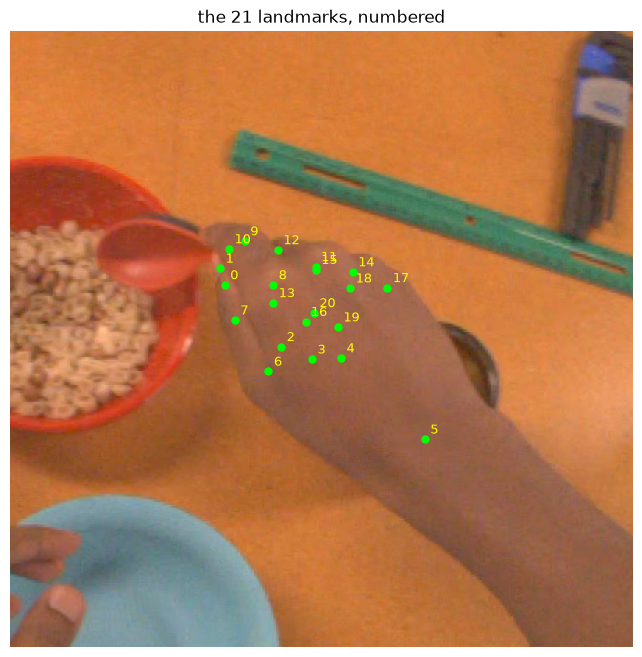

In [19]:
# The hand gives us 21 landmarks but we do not know which index is the thumb
# tip or the index fingertip. Projecting them all into the image with their
# numbers printed on top tells us directly.
hand_at_start = vrs_data_provider.get_interpolated_hand_pose_data(
    hand_sid, t_ns, TimeDomain.DEVICE_TIME)

side = hand_at_start.right_hand
lm = np.asarray(side.landmark_positions_device).reshape(-1, 3)
print(f"landmarks: {lm.shape}")

# Each landmark goes through the same route as the point clouds did, from the
# device frame into the RGB camera and then onto a pixel.
lm_rgb = (lm - t_rgb) @ R_rgb

pix = []
for p in lm_rgb:
    q = rgb_calib.project(p) if p[2] > 0 else None
    pix.append([float(q[0]), float(q[1])] if q is not None else [np.nan, np.nan])
pix = np.array(pix)

print(f"landmarks which project onto the image: {np.isfinite(pix[:, 0]).sum()} of 21")

# We crop around the hand so the numbers are readable rather than lost in two
# million pixels.
ok_pix = pix[np.isfinite(pix[:, 0])]
x0, x1 = int(ok_pix[:, 0].min()) - 150, int(ok_pix[:, 0].max()) + 150
y0, y1 = int(ok_pix[:, 1].min()) - 150, int(ok_pix[:, 1].max()) + 150
x0, y0 = max(0, x0), max(0, y0)
x1, y1 = min(rgb_img.shape[1], x1), min(rgb_img.shape[0], y1)

plt.figure(figsize=(11, 8))
plt.imshow(rgb_img[y0:y1, x0:x1])
for i, (u, v) in enumerate(pix):
    if not np.isfinite(u):
        continue
    plt.plot(u - x0, v - y0, "o", color="lime", markersize=5)
    plt.annotate(str(i), (u - x0, v - y0), color="yellow",
                 fontsize=9, xytext=(4, 4), textcoords="offset points")
plt.axis("off")
plt.title("the 21 landmarks, numbered")
plt.show()

In [20]:
# The numbering is not one we recognise, so we identify it rather than assume.
# The device reports the wrist through its own method, so whichever landmark
# sits closest to that is the wrist landmark.
wrist_p = np.asarray(side.get_wrist_position_device()).reshape(-1)[:3]
palm_p = np.asarray(side.get_palm_position_device()).reshape(-1)[:3]

d_wrist = np.linalg.norm(lm - wrist_p, axis=1)
d_palm = np.linalg.norm(lm - palm_p, axis=1)

print(f"landmark closest to the reported wrist: {int(np.argmin(d_wrist))} "
      f"at {d_wrist.min()*1000:.1f} mm")
print(f"landmark closest to the reported palm : {int(np.argmin(d_palm))} "
      f"at {d_palm.min()*1000:.1f} mm")
print()

# Sorting everything by distance from the wrist exposes the structure. The
# knuckles sit close in, the fingertips sit furthest out and the gaps between
# them should show where one finger ends and the next begins.
order = np.argsort(d_wrist)
print("landmark   distance from wrist")
for i in order:
    print(f"{i:>8}   {d_wrist[i]*100:>6.1f} cm")

landmark closest to the reported wrist: 5 at 0.0 mm
landmark closest to the reported palm : 20 at 0.0 mm

landmark   distance from wrist
       5      0.0 cm
       4      7.1 cm
       6      7.4 cm
      20      7.5 cm
      17      7.8 cm
       3      7.8 cm
      14      8.1 cm
      11      8.6 cm
      19      8.9 cm
       8      8.9 cm
       2      9.0 cm
      18      9.7 cm
      16      9.7 cm
       7     10.1 cm
      15     10.7 cm
      13     10.8 cm
      12     11.6 cm
       9     11.9 cm
       0     12.0 cm
      10     13.1 cm
       1     14.0 cm


palm to fingertip centroid: 5.0 cm

    0 cm past the fingertips: pixel (1105, 789)
    2 cm past the fingertips: pixel (1085, 775)
    4 cm past the fingertips: pixel (1066, 761)
    6 cm past the fingertips: pixel (1048, 748)
    8 cm past the fingertips: pixel (1031, 736)
   10 cm past the fingertips: pixel (1015, 724)


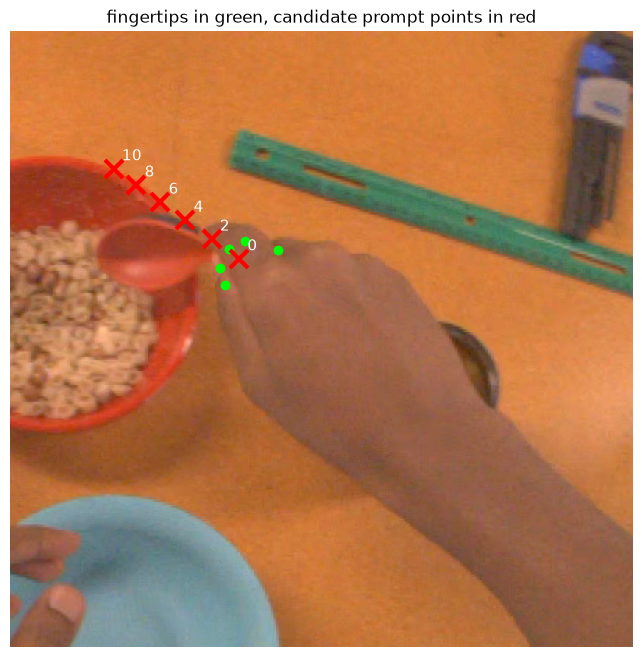

In [21]:
# The five landmarks furthest from the wrist are the fingertips. We take their
# centroid as a starting point, then walk outward along the line running from
# the palm through that centroid, since a held object continues past the
# fingers rather than sitting between them.
FINGERTIPS = [1, 10, 0, 9, 12]

tip_centre = lm[FINGERTIPS].mean(axis=0)
palm_pos = lm[20]

direction = tip_centre - palm_pos
direction = direction / np.linalg.norm(direction)

print(f"palm to fingertip centroid: {np.linalg.norm(tip_centre - palm_pos)*100:.1f} cm")
print()

# Several candidates at increasing distance past the fingertips. Looking at
# where each one lands tells us how far out the prompt needs to be, rather than
# us picking a number and hoping it works.
offsets = [0.0, 0.02, 0.04, 0.06, 0.08, 0.10]
candidates = [tip_centre + direction * o for o in offsets]

cand_pix = []
for p in candidates:
    p_cam = (p - t_rgb) @ R_rgb
    q = rgb_calib.project(p_cam) if p_cam[2] > 0 else None
    cand_pix.append([float(q[0]), float(q[1])] if q is not None else [np.nan, np.nan])
cand_pix = np.array(cand_pix)

for o, (u, v) in zip(offsets, cand_pix):
    print(f"{o*100:>5.0f} cm past the fingertips: pixel ({u:.0f}, {v:.0f})")

plt.figure(figsize=(11, 8))
plt.imshow(rgb_img[y0:y1, x0:x1])

# The fingertips in green so we can see where the hand ends.
for i in FINGERTIPS:
    plt.plot(pix[i, 0] - x0, pix[i, 1] - y0, "o", color="lime", markersize=6)

# The candidates in red, numbered by how far out they sit.
for o, (u, v) in zip(offsets, cand_pix):
    if not np.isfinite(u):
        continue
    plt.plot(u - x0, v - y0, "x", color="red", markersize=13, markeredgewidth=3)
    plt.annotate(f"{o*100:.0f}", (u - x0, v - y0), color="white",
                 fontsize=11, xytext=(6, 6), textcoords="offset points")

plt.axis("off")
plt.title("fingertips in green, candidate prompt points in red")
plt.show()

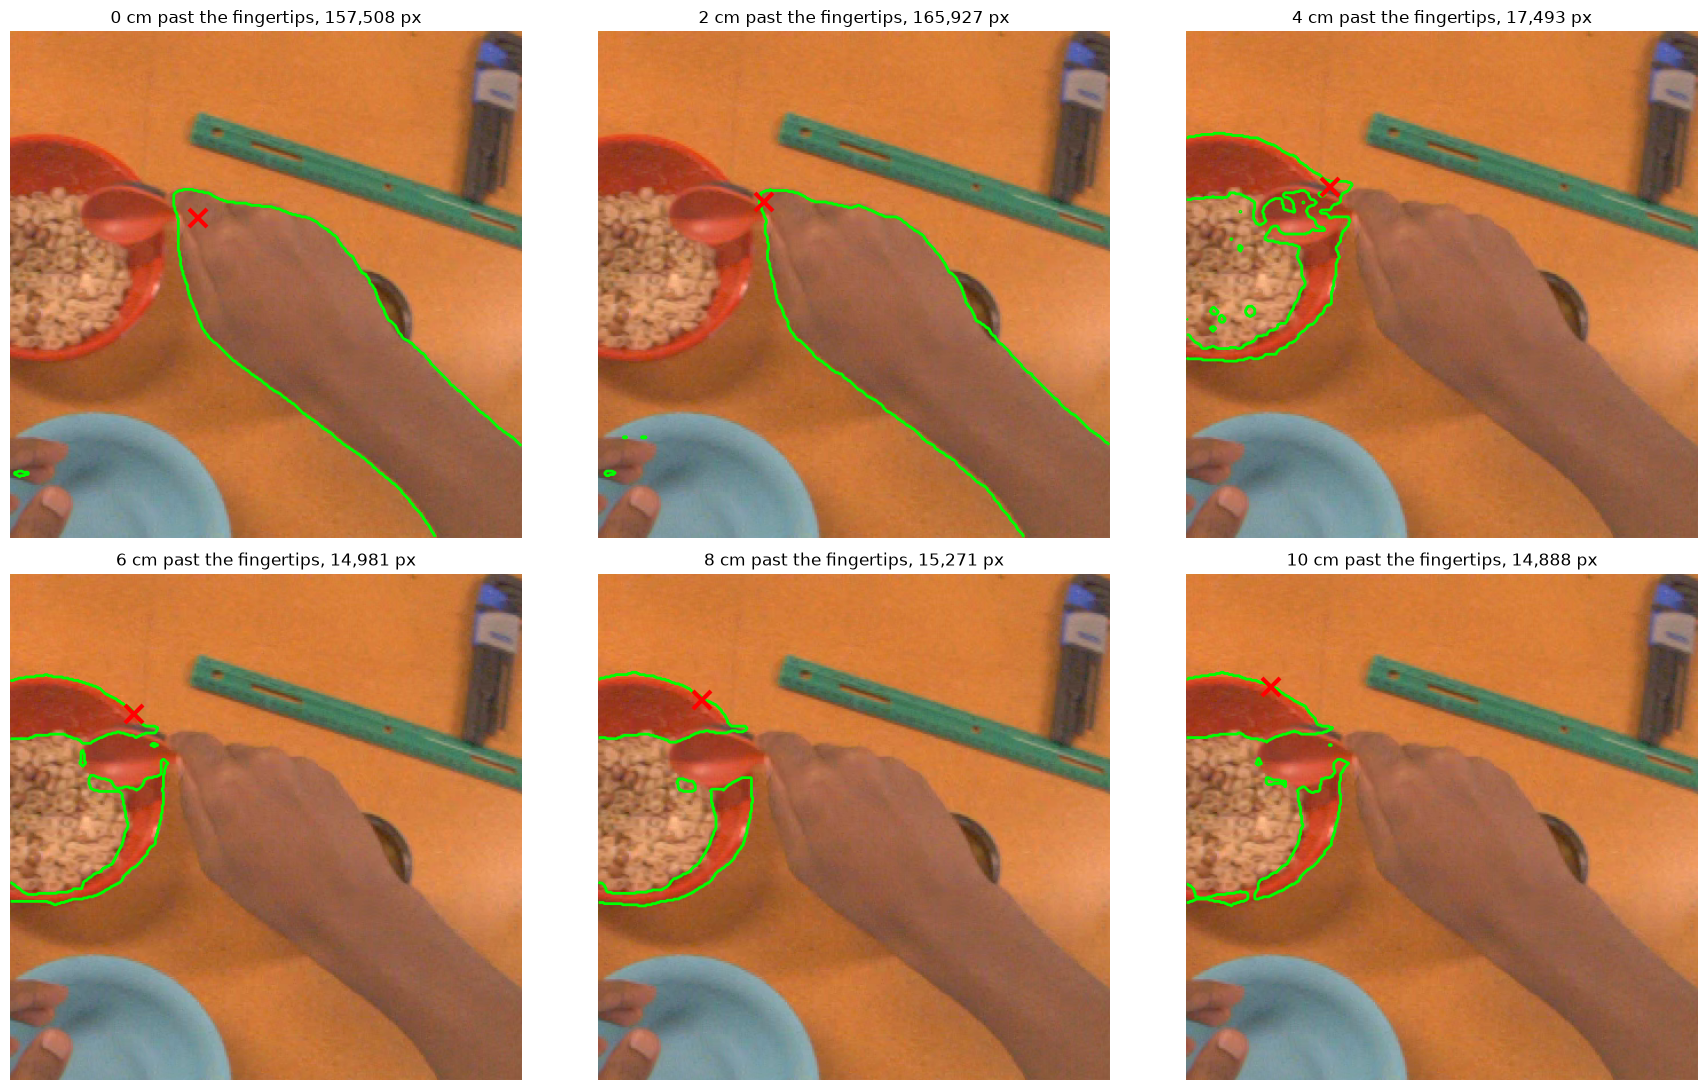

In [22]:
# Six candidates, six masks. Whichever one produces a mask that looks like the
# spoon is the rule we adopt. This decides it by running the thing rather than by
# me reading a compressed picture.
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for ax, o, (u, v) in zip(axes.flat, offsets, cand_pix):
    if not np.isfinite(u):
        ax.axis("off")
        ax.set_title(f"{o*100:.0f} cm, does not project")
        continue

    res = sam(rgb_img, points=[[float(u), float(v)]], labels=[1], verbose=False)[0]
    m = res.masks.data[0].cpu().numpy() > 0.5

    ax.imshow(rgb_img[y0:y1, x0:x1])
    ax.contour(m[y0:y1, x0:x1], levels=[0.5], colors="lime", linewidths=2)
    ax.plot(u - x0, v - y0, "x", color="red", markersize=13, markeredgewidth=3)
    ax.set_title(f"{o*100:.0f} cm past the fingertips, {m.sum():,} px")
    ax.axis("off")

plt.tight_layout()
plt.show()

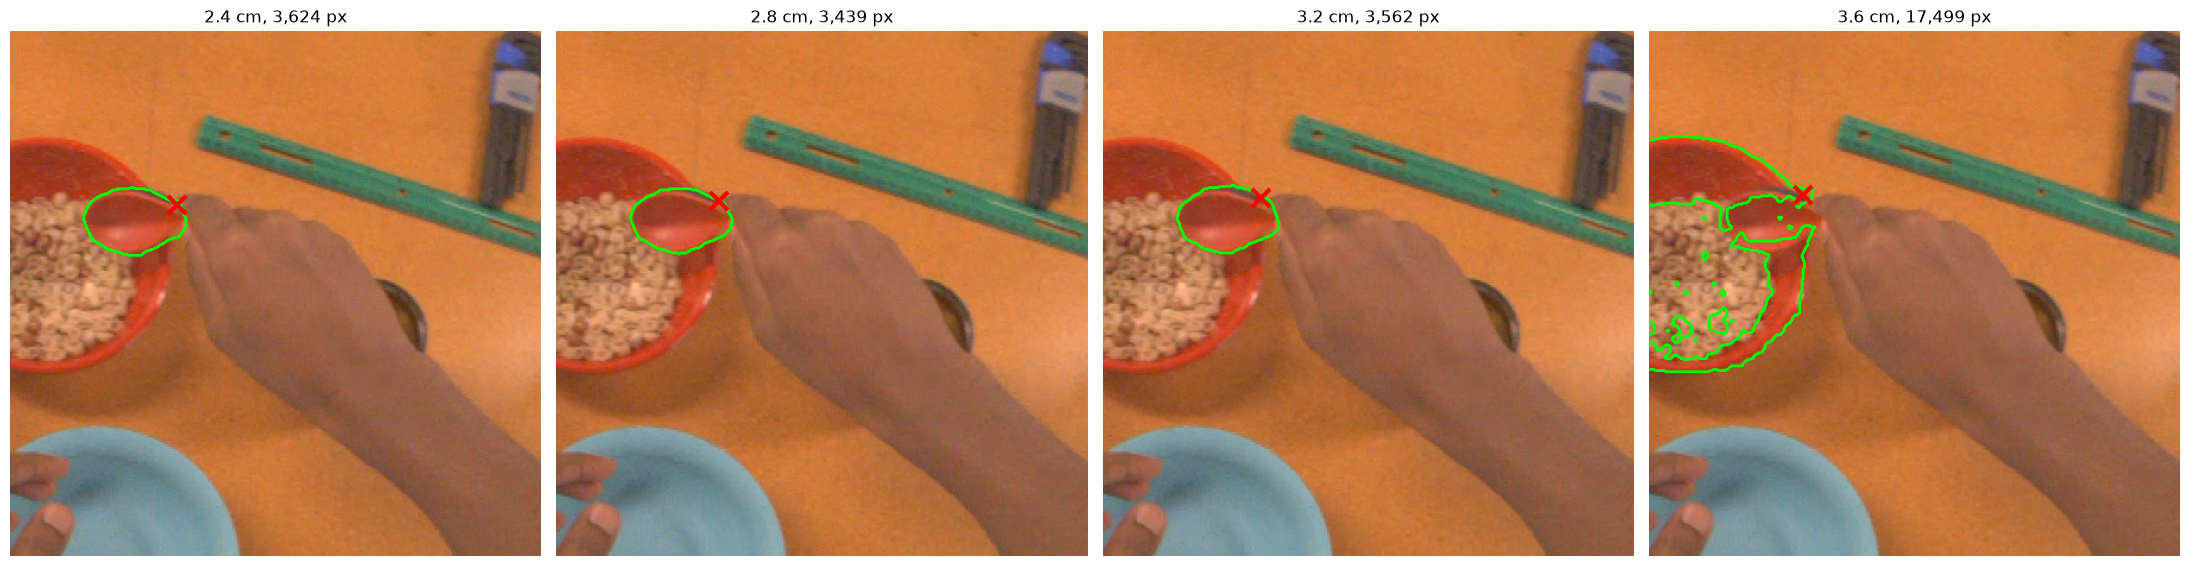

eye gaze fields: ['combined_gaze_origin_in_cpf', 'combined_gaze_valid', 'depth', 'pitch', 'pitch_high', 'pitch_low', 'session_uid', 'spatial_gaze_point_in_cpf', 'spatial_gaze_point_valid', 'tracking_timestamp', 'vergence', 'yaw', 'yaw_high', 'yaw_low']


In [23]:
# The jump from hand to bowl happened between 2 and 4 cm, so the ray crosses the
# handle somewhere in that gap. A finer sweep tells us whether it can be caught.
fine = [0.024, 0.028, 0.032, 0.036]

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
for ax, o in zip(axes, fine):
    p = tip_centre + direction * o
    p_cam = (p - t_rgb) @ R_rgb
    q = rgb_calib.project(p_cam)
    u, v = float(q[0]), float(q[1])

    res = sam(rgb_img, points=[[u, v]], labels=[1], verbose=False)[0]
    m = res.masks.data[0].cpu().numpy() > 0.5

    ax.imshow(rgb_img[y0:y1, x0:x1])
    ax.contour(m[y0:y1, x0:x1], levels=[0.5], colors="lime", linewidths=2)
    ax.plot(u - x0, v - y0, "x", color="red", markersize=13, markeredgewidth=3)
    ax.set_title(f"{o*100:.1f} cm, {m.sum():,} px")
    ax.axis("off")
plt.tight_layout()

# Save before show. show() closes the figure, so anything saved after it comes
# out as a blank white image.
plt.savefig(OUTPUTS / "hand_offset_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

# Gaze is the other route Dasha mentioned. The wearer looks at what they are
# manipulating, so a gaze ray lands on the object instead of beside it. Before
# using it we need to know what the eye gaze record actually contains.
gaze_sid = vrs_data_provider.get_stream_id_from_label("eyegaze")
gz = vrs_data_provider.get_eye_gaze_data_by_time_ns(
    gaze_sid, t_ns, TimeDomain.DEVICE_TIME, TimeQueryOptions.CLOSEST)

print("eye gaze fields:", [a for a in dir(gz) if not a.startswith("_")])

In [24]:
# The gaze point comes in the Central Pupil Frame rather than the device frame,
# so we need the transform between them before we can use it.
print("cpf related methods:",
      [m for m in dir(device_calib) if "cpf" in m.lower()])
print()

print("gaze valid:", gz.spatial_gaze_point_valid)
print("raw gaze point in cpf:", np.asarray(gz.spatial_gaze_point_in_cpf).reshape(-1))
print("depth:", gz.depth)
print("vergence:", gz.vergence)

cpf related methods: ['get_transform_cpf_sensor', 'get_transform_device_cpf']

gaze valid: True
raw gaze point in cpf: [   0.072476   -0.094926     0.57585]
depth: 0.5946739912033081
vergence: <_core_pybinds.mps.EyeGazeVergence object at 0x1268d62b0>


gaze point in the device frame: [0.196, -0.104, 0.529] m
object centre we measured earlier: [0.282, -0.149, 0.608] m
distance between them: 12.6 cm

gaze projects to pixel (971, 827)
mask from the gaze prompt: 18,238 pixels


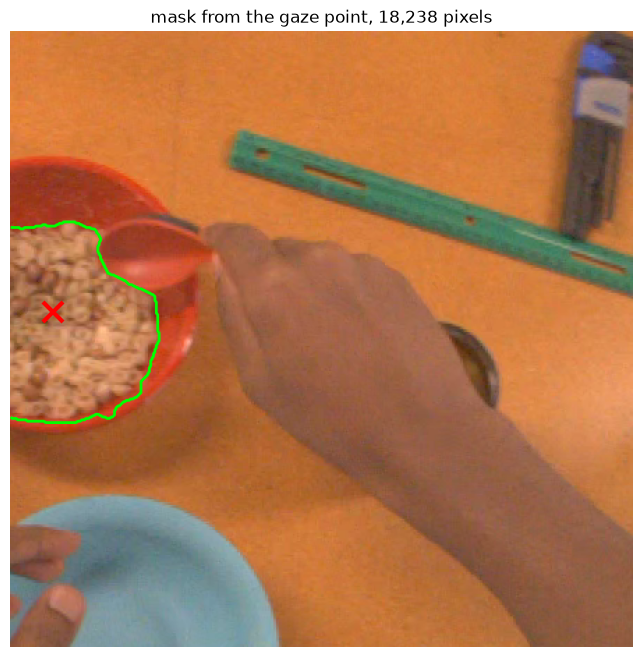

In [25]:
# The gaze point is reported in the Central Pupil Frame, so we move it into the
# device frame where the rest of our work lives.
T_device_cpf = device_calib.get_transform_device_cpf()
R_cpf = np.asarray(T_device_cpf.rotation().to_matrix())
t_cpf = np.asarray(T_device_cpf.translation()).reshape(-1)

gaze_cpf = np.asarray(gz.spatial_gaze_point_in_cpf).reshape(-1)[:3]
gaze_device = R_cpf @ gaze_cpf + t_cpf

print(f"gaze point in the device frame: "
      f"[{gaze_device[0]:.3f}, {gaze_device[1]:.3f}, {gaze_device[2]:.3f}] m")

# We already know where the spoon was from the manual prompt, so we can check
# straight away whether the wearer was actually looking at it.
print(f"object centre we measured earlier: "
      f"[{centre[0]:.3f}, {centre[1]:.3f}, {centre[2]:.3f}] m")
print(f"distance between them: {np.linalg.norm(gaze_device - centre)*100:.1f} cm")
print()

# And into a pixel, which is what SAM needs.
g_cam = (gaze_device - t_rgb) @ R_rgb
gq = rgb_calib.project(g_cam)
gu, gv = float(gq[0]), float(gq[1])
print(f"gaze projects to pixel ({gu:.0f}, {gv:.0f})")

res = sam(rgb_img, points=[[gu, gv]], labels=[1], verbose=False)[0]
gmask = res.masks.data[0].cpu().numpy() > 0.5
print(f"mask from the gaze prompt: {gmask.sum():,} pixels")

plt.figure(figsize=(11, 8))
plt.imshow(rgb_img[y0:y1, x0:x1])
plt.contour(gmask[y0:y1, x0:x1], levels=[0.5], colors="lime", linewidths=2)
plt.plot(gu - x0, gv - y0, "x", color="red", markersize=14, markeredgewidth=3)
plt.axis("off")
plt.title(f"mask from the gaze point, {gmask.sum():,} pixels")
plt.show()

In [26]:
print(calibration.distort_by_calibration_and_apply_rotation.__doc__)

distort_by_calibration_and_apply_rotation(*args, **kwargs)
Overloaded function.

1. distort_by_calibration_and_apply_rotation(arraySrc: typing.Annotated[numpy.typing.ArrayLike, numpy.uint8], dstCalib: _core_pybinds.calibration.CameraCalibration, srcCalib: _core_pybinds.calibration.CameraCalibration, so3_srcCalib_dstCalib: SO3, method: _core_pybinds.image.InterpolationMethod = <InterpolationMethod.BILINEAR: 1>) -> numpy.typing.NDArray[numpy.float32] | numpy.typing.NDArray[numpy.uint8] | numpy.typing.NDArray[numpy.uint16] | numpy.typing.NDArray[numpy.uint64] | numpy.typing.NDArray[Eigen::half]

Distorts an input image to swap its underlying image distortion model, while applying a rotation to the camera ray. This can be used for stereo rectification.

2. distort_by_calibration_and_apply_rotation(arraySrc: typing.Annotated[numpy.typing.ArrayLike, numpy.float32], dstCalib: _core_pybinds.calibration.CameraCalibration, srcCalib: _core_pybinds.calibration.CameraCalibration, so3_srcCalib_dstCa

columns: ['frame', 'time_s', 'n_points', 'device_x', 'device_y', 'device_z', 'world_x', 'world_y', 'world_z']
device frame columns picked: ['device_x', 'device_y', 'device_z']
room frame columns picked:   ['world_x', 'world_y', 'world_z']
device frame x span: 6.0 cm
room frame x span:   18.8 cm


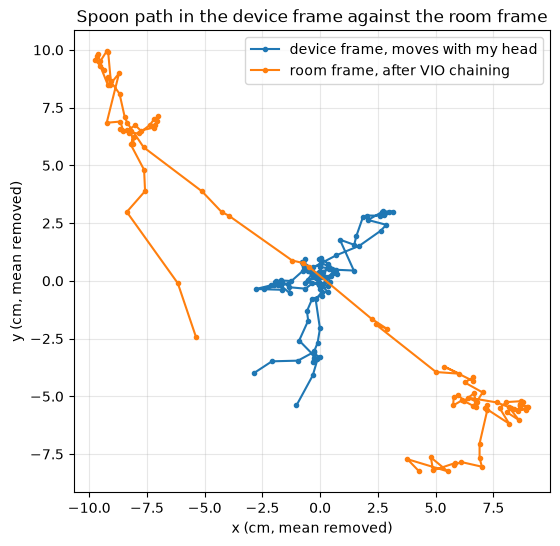

saved to /Users/harshdas/Desktop/Rinzler/Stony Brook University/Advanced Project/Meta-Aria-Gen-2-Robotics/outputs/trajectory_device_vs_room.png


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = OUTPUTS

# We read the trajectory back off disk rather than using whatever is still sitting
# in memory, because the CSV is what you are actually sending him and we want the
# picture to come from the same place as the file.
df = pd.read_csv(OUT / "spoon_trajectory.csv")

# What is really in this file ? We print it before anything else, so that if the
# guess below grabs the wrong columns you find out now rather than after staring
# at a plot that looks reasonable.
print("columns:", df.columns.tolist())

# We find the two sets of coordinates by name instead of by position. The device
# frame ones normally carry "dev" and the room frame ones carry "world", "room"
# or "odom", so we search for those words.
dev_cols  = [c for c in df.columns if "dev" in c.lower()]
room_cols = [c for c in df.columns if any(k in c.lower() for k in ("world", "room", "odom"))]

print("device frame columns picked:", dev_cols)
print("room frame columns picked:  ", room_cols)

# If either of those came out wrong, set them by hand right here and run again.
# For eg. dev_cols = ["x_dev", "y_dev", "z_dev"]

dev  = df[dev_cols[:3]].to_numpy(dtype=float)
room = df[room_cols[:3]].to_numpy(dtype=float)

# The frames where tracking dropped out are NaN. A single NaN would poison the
# span numbers below, so we keep only the rows where both frames have a value.
good = ~np.isnan(dev).any(axis=1) & ~np.isnan(room).any(axis=1)
dev, room = dev[good], room[good]

# The two paths live in different coordinate systems, so drawing them on the same
# axes only means something once we take the mean out of each one. What is left
# after that is purely how far the object travelled, which is the thing we want to
# compare.
dev_c  = dev  - dev.mean(axis=0)
room_c = room - room.mean(axis=0)

# These are the numbers quoted in the email, worked out here rather than typed in
# by hand, so the picture and the text cannot drift apart from each other.
print(f"device frame x span: {np.ptp(dev_c[:, 0]) * 100:.1f} cm")
print(f"room frame x span:   {np.ptp(room_c[:, 0]) * 100:.1f} cm")

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(dev_c[:, 0] * 100,  dev_c[:, 1] * 100,  "-o", ms=3, label="device frame, moves with my head")
ax.plot(room_c[:, 0] * 100, room_c[:, 1] * 100, "-o", ms=3, label="room frame, after VIO chaining")

# Equal aspect is doing real work here. If the axes are allowed to stretch on their
# own then the smaller path gets blown up to fill the box. The entire point of the
# picture then disappears.
ax.set_aspect("equal")
ax.set_xlabel("x (cm, mean removed)")
ax.set_ylabel("y (cm, mean removed)")
ax.set_title("Spoon path in the device frame against the room frame")
ax.legend()
ax.grid(alpha=0.3)

# Save before show. This is exactly why the last attempt came out white: show()
# closes the figure, so any savefig after it writes an empty canvas.
fig.savefig(OUT / "trajectory_device_vs_room.png", dpi=150, bbox_inches="tight")
plt.show()

print("saved to", OUT / "trajectory_device_vs_room.png")

In [28]:
# Every number the weekly report quotes should be recoverable from this notebook rather
# than from a shell session that no longer exists. Two figures were failing that test, so
# we measure them here. Why read the csv back off disk instead of using what is still
# sitting in memory ? Because the csv is the file we actually sent him, so if the two ever
# disagree we want to hear it from the file.
import pandas as pd

df = pd.read_csv(OUTPUTS / "spoon_trajectory.csv")

# The median on its own hides how uneven the point count is from one frame to the next,
# and that spread is the honest picture of how much of the object the depth map found.
print("points per frame, across the 100 tracked frames")
print(f"  frames : {len(df)}")
print(f"  minimum: {df['n_points'].min()}")
print(f"  maximum: {df['n_points'].max()}")
print(f"  median : {df['n_points'].median():.0f}")
print(f"  total  : {df['n_points'].sum():,}")
print()

# Now the two pose streams. The report says the high frequency one runs at roughly 800 Hz,
# and a claim like that has to come from the recording rather than from a specification
# page, because the two have already disagreed once on this project.
print("pose stream rates, measured from this recording")
for label in ["vio", "vio_high_frequency"]:
    sid = vrs_data_provider.get_stream_id_from_label(label)

    # Counting the samples and dividing by the span they cover gives the average rate.
    # That is all we need here, since we are choosing between 10 and 800 rather than
    # chasing jitter between one sample and the next.
    n = vrs_data_provider.get_num_data(sid)
    t0 = vrs_data_provider.get_first_time_ns(sid, TimeDomain.DEVICE_TIME)
    t1 = vrs_data_provider.get_last_time_ns(sid, TimeDomain.DEVICE_TIME)
    span_s = (t1 - t0) / 1e9

    print(f"  {label:20} {n:>7,} samples over {span_s:6.2f} s  =  {n / span_s:6.1f} Hz")

# One thing those spans settle, which is easy to assume wrongly. Do both streams cover the
# same stretch of the recording ? They do not quite, so anything that switches over to the
# high frequency stream has to check that its window falls inside the shorter span.
vio_sid = vrs_data_provider.get_stream_id_from_label("vio")
hf_sid = vrs_data_provider.get_stream_id_from_label("vio_high_frequency")

def span_of(sid):
    """How many seconds of the recording does this stream actually cover ?"""
    t0 = vrs_data_provider.get_first_time_ns(sid, TimeDomain.DEVICE_TIME)
    t1 = vrs_data_provider.get_last_time_ns(sid, TimeDomain.DEVICE_TIME)
    return (t1 - t0) / 1e9

print()
print(f"the high frequency stream covers {span_of(vio_sid) - span_of(hf_sid):.2f} s less "
      f"of the recording than the 10 Hz one")

# For eg. our tracked window runs from 32.5 s to 35.8 s, which sits comfortably inside
# both of them, so the shorter coverage costs us nothing today.

points per frame, across the 100 tracked frames
  frames : 100
  minimum: 84
  maximum: 541
  median : 187
  total  : 20,518

pose stream rates, measured from this recording
  vio                      670 samples over  67.00 s  =    10.0 Hz
  vio_high_frequency    52,295 samples over  65.86 s  =   794.1 Hz

the high frequency stream covers 1.14 s less of the recording than the 10 Hz one
